# Exploratory Data Analysis to understand the dataset before building classifiers — class balance, text lengths, source coverage, gaps.

The purpose of this EDA is to understand the dataset and identify which features carry signal for classification. For text classification there are two types of features: **text features** (the article text itself, which TF-IDF will extract patterns from) and **metadata features** (item type, organisation category, text length, etc.).

A good feature is one that helps distinguish between categories. It should vary across categories, carry consistent signal rather than noise, be available at prediction time, and add information not already captured by other features. The process is: visualise each feature against the target (cross-tabs, heatmaps), check whether distributions differ across categories, and use domain knowledge to assess relevance. Features derived from the same source (e.g. `organisation` and `org_category`) are redundant — pick one.

We also explore the most common words per category to check whether categories have distinct vocabularies — if they do, TF-IDF will work well.



# 00_data and imports 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [2]:
df = pd.read_csv("../data/preprocessed/newsletters_preprocessed.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (1654, 18)


,id,newsletter_number,issue_date,theme,subtheme,title,description,link,new_theme,domain,organisation,org_broad_category,org_category,item_type,title_length,description_length,text,text_length_words
0,a65013c4-ce18-43d8-82a5-b7707d8ecce9,1,11 July 2023,DfE,NaN,"Reject fewer teacher applicants, DfE tells trainers","Susan Acland-Hood, the DfE's permanent secretary, told providers a 7 per cen...",https://schoolsweek.co.uk/reject-fewer-teacher-applicants-dfe-tells-trainers,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,51,163.0,"Reject fewer teacher applicants, DfE tells trainers Susan Acland-Hood, the D...",35
1,550a3ffb-c512-4117-b6fa-eff93855fd89,1,11 July 2023,DfE,NaN,Revealed: the experts advising ministers on teacher training reforms review,"The Department for Education has appointed an ""external steering group"" to r...",https://schoolsweek.co.uk/revealed-the-experts-advising-ministers-on-teacher...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,75,408.0,Revealed: the experts advising ministers on teacher training reforms review ...,74
2,c79baa9f-775b-444e-bbd4-dc111e4846f4,1,11 July 2023,Calls for evidence,NaN,Deadline 23 August 2023,Education secretary Gillian Keegan has launched a call for evidence on using...,https://schoolsweek.co.uk/chatgpt-keegan-launches-call-for-evidence-on-ai-in...,policy_practice_research,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,23,174.0,Deadline 23 August 2023 Education secretary Gillian Keegan has launched a ca...,32


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1654 non-null   object 
 1   newsletter_number   1654 non-null   int64  
 2   issue_date          1654 non-null   object 
 3   theme               1654 non-null   object 
 4   subtheme            95 non-null     object 
 5   title               1654 non-null   object 
 6   description         1354 non-null   object 
 7   link                1654 non-null   object 
 8   new_theme           1654 non-null   object 
 9   domain              1643 non-null   object 
 10  organisation        1399 non-null   object 
 11  org_broad_category  1399 non-null   object 
 12  org_category        1399 non-null   object 
 13  item_type           1654 non-null   object 
 14  title_length        1654 non-null   int64  
 15  description_length  1354 non-null   float64
 16  text  

In [4]:
df.columns

Index(['id', 'newsletter_number', 'issue_date', 'theme', 'subtheme', 'title',
       'description', 'link', 'new_theme', 'domain', 'organisation',
       'org_broad_category', 'org_category', 'item_type', 'title_length',
       'description_length', 'text', 'text_length_words'],
      dtype='object')

**Note:** With 1,654 samples, traditional ML (TF-IDF + logistic regression, SVM) or fine-tuned transformers (e.g. BERT) are viable approaches. Training a transformer from scratch is not feasible with this dataset size.


# 01_Create Target Variable

In [5]:
df["new_theme"].value_counts()

new_theme
political_environment_key_organisations    315
what_matters_ed                            256
teacher_rrd                                233
edtech                                     226
policy_practice_research                   221
four_nations                               165
update_from_pi                             143
update_from_programme                       95
Name: count, dtype: int64

**Note:** Dropping `update_from_pi` (143) and `update_from_programme` (95) as these categories come directly from the curator rather than being derived from article content.

In [6]:
#create new target variable without 'updates' categories 
df["target"] = df["new_theme"]
df = df[df["target"].isin(["political_environment_key_organisations", "what_matters_ed", "teacher_rrd", "edtech", "policy_practice_research", "four_nations"])]
df["target"].value_counts()

target
political_environment_key_organisations    315
what_matters_ed                            256
teacher_rrd                                233
edtech                                     226
policy_practice_research                   221
four_nations                               165
Name: count, dtype: int64

# 02_Text length distribution

How long is the combined text (title + description)? This is the input the classifier will use.


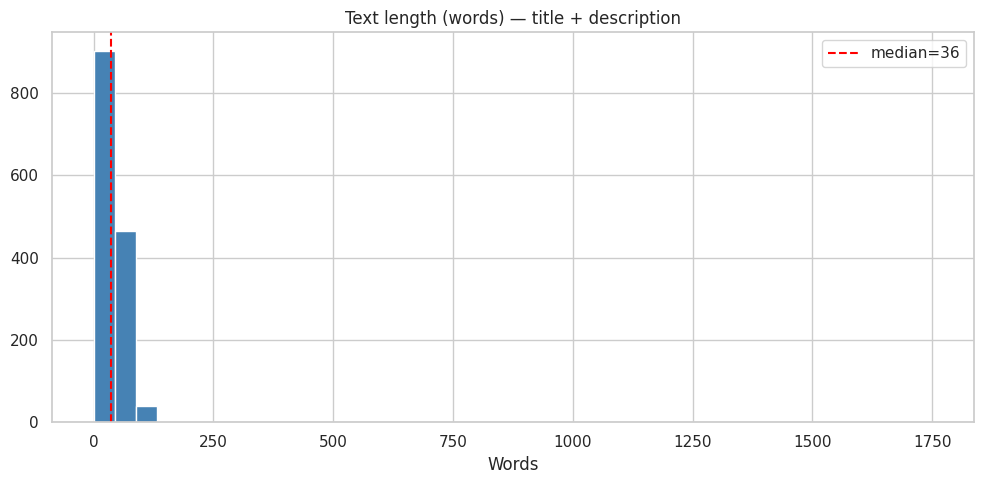

count    1416.0
mean       42.2
std        55.3
min         1.0
25%        25.0
50%        36.0
75%        51.0
max      1750.0
Name: text_length_words, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
df["text_length_words"].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Text length (words) — title + description")
ax.set_xlabel("Words")
ax.axvline(df["text_length_words"].median(), color="red", linestyle="--", label=f'median={df["text_length_words"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

df["text_length_words"].describe().round(1)


In [24]:
# how many short articles
for n in [3, 5, 10, 15, 20]:
    print(f"Under {n} words: {(df['text_length_words'] < n).sum()}")


Under 3 words: 0
Under 5 words: 0
Under 10 words: 0
Under 15 words: 0
Under 20 words: 83


In [10]:
print(f"Before: {len(df)}")
df = df[df["text_length_words"] >= 15]
print(f"After: {len(df)}")
df["target"].value_counts()


Before: 1416
After: 1287


target
political_environment_key_organisations    266
what_matters_ed                            231
teacher_rrd                                218
edtech                                     212
policy_practice_research                   207
four_nations                               153
Name: count, dtype: int64

**Data cleaning:** Dropped 129 rows with fewer than 15 words. These were mostly junk items picked up by the scraper — sub-links, email signups, bylines — or real articles with missing descriptions that lack enough text for classification. This removes ~9% of the data.


# 03_Unmapped organisations

In [11]:
print(f"Unmapped organisations: {df['organisation'].isna().sum()} / {len(df)} ({df['organisation'].isna().mean()*100:.1f}%)")


Unmapped organisations: 178 / 1287 (13.8%)


In [12]:
df[df["organisation"].isna()]["domain"].value_counts().head(15)


domain
www.eventbrite.co.uk               20
meetoecd1.zoom.us                   8
lgiu.us3.list-manage.com            7
education.us18.list-manage.com      7
parliament.us16.list-manage.com     7
defenddigitalme.org                 6
d2tic4wvo1iusb.cloudfront.net       5
bit.ly                              5
forms.office.com                    4
t.co                                3
www.eventbrite.com                  3
drive.google.com                    2
open.spotify.com                    2
politico.us8.list-manage.com        2
www.evaluation.impactedgroup.uk     2
Name: count, dtype: int64

In [13]:
print(f"Before: {len(df)}")
df = df[df["organisation"].notna()]
print(f"After: {len(df)}")
df["target"].value_counts()


Before: 1287
After: 1109


target
political_environment_key_organisations    239
what_matters_ed                            197
teacher_rrd                                194
edtech                                     175
policy_practice_research                   160
four_nations                               144
Name: count, dtype: int64

**Unmapped organisations:** 178 rows (13.8%) have no mapped organisation. These are mostly platform/utility domains (eventbrite, zoom, list-manage, bit.ly, forms.office.com) rather than real article sources. Dropped as they are not article content and would not appear in the inference pipeline.


# 04_Class Imbalance

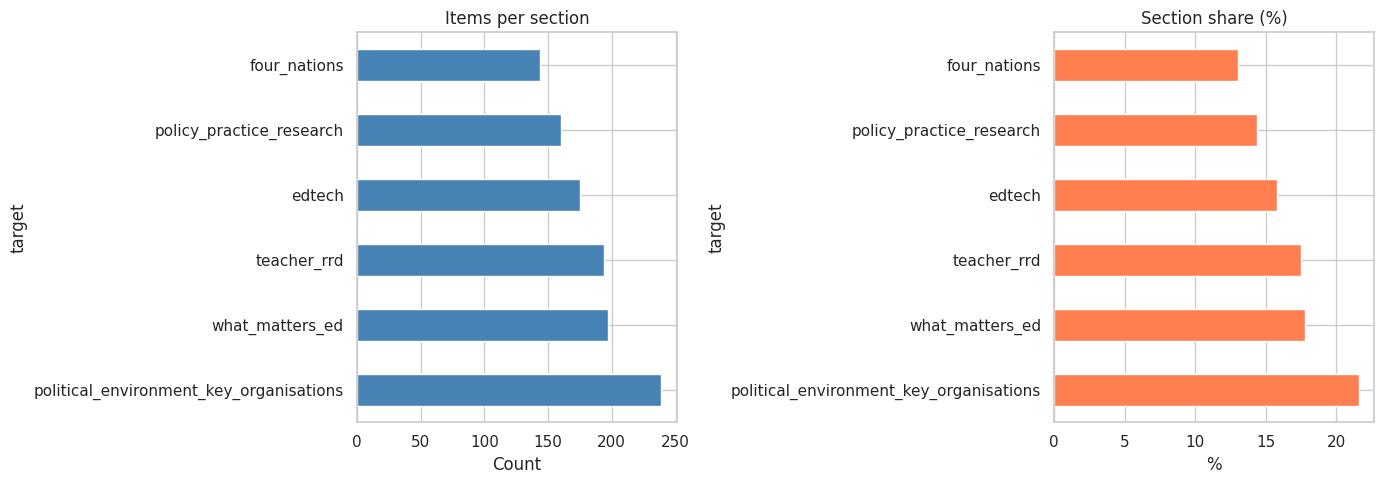

,count,pct
target,,
political_environment_key_organisations,239,21.6
what_matters_ed,197,17.8
teacher_rrd,194,17.5
edtech,175,15.8
policy_practice_research,160,14.4
four_nations,144,13.0


In [22]:
theme_counts = df["target"].value_counts()
theme_pct = df["target"].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

theme_counts.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Items per section")
axes[0].set_xlabel("Count")

theme_pct.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Section share (%)")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.show()

pd.DataFrame({"count": theme_counts, "pct": theme_pct})


**Class balance:** Mildly imbalanced but not problematic. The top 4 classes are tightly clustered (14.4%–21.6%). `four_nations` is the smallest at 13.0% (144 samples) — expect slightly weaker performance on this class. No aggressive resampling needed; stratified splits and class weights should be sufficient.


# 05_keywords for each category

In [15]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
X = tfidf.fit_transform(df["text"])
feature_names = tfidf.get_feature_names_out()

for cat in sorted(df["target"].unique()):
    mask = (df["target"] == cat).values
    mean_tfidf = X[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"\n{cat}:")
    print(", ".join(top_words))


edtech:
digital, education, children, schools, use, edtech, intelligence, report, artificial, ban, generative, technology, online, impact, new

four_nations:
education, scottish, government, wales, welsh, northern, ireland, child, minister, scotland, learning, new, poverty, belfast, telegraph

policy_practice_research:
research, policy, education, evidence, blog, local, university, impact, upen, engagement, innovation, report, practice, knowledge, new

political_environment_key_organisations:
schools, education, government, ofsted, report, school, children, send, new, curriculum, labour, schoolsweek, review, england, dfe

teacher_rrd:
teacher, teachers, retention, recruitment, schools, teaching, pay, school, report, education, training, schoolsweek, workforce, nfer, england

what_matters_ed:
children, school, report, send, education, schools, pupils, absence, health, needs, poverty, england, young, support, government


**Top words by category:** Categories have distinct vocabularies, suggesting TF-IDF will be effective. `edtech` features tech terms (digital, AI, generative, technology), `four_nations` is geographic (Wales, Scottish, Northern Ireland, Belfast), `teacher_rrd` is workforce-focused (retention, recruitment, pay, training), and `policy_practice_research` is academic (research, evidence, university, impact). Some overlap between `political_environment_key_organisations` and `what_matters_ed` — both reference children, schools, and SEND — which may be a source of misclassification.


# 06_Item type breakdown

#### What proportion are news articles vs reports vs academic papers? This tells us what kind of text the classifier will see and whether item type could be a useful feature.


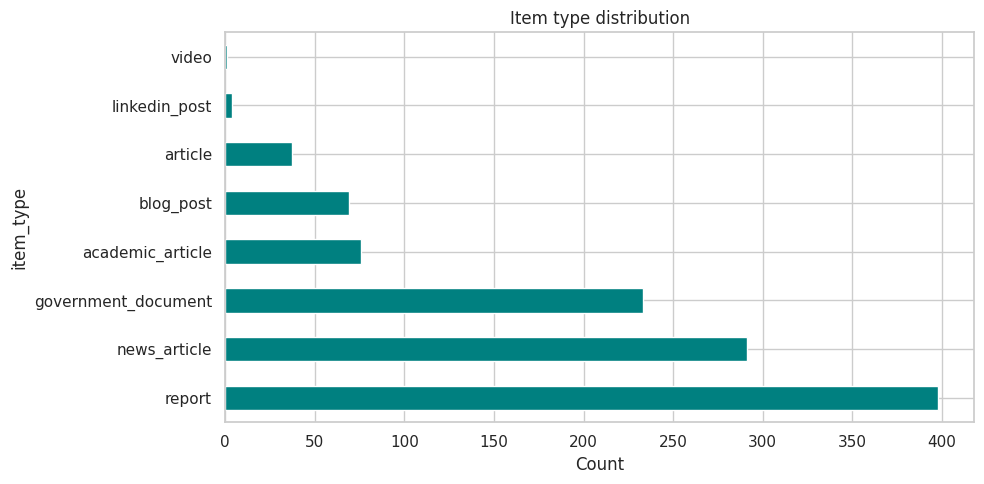

item_type
report                 398
news_article           291
government_document    233
academic_article        76
blog_post               69
article                 37
linkedin_post            4
video                    1
Name: count, dtype: int64

In [16]:
item_counts = df["item_type"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
item_counts.plot.barh(ax=ax, color="teal")
ax.set_title("Item type distribution")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

item_counts


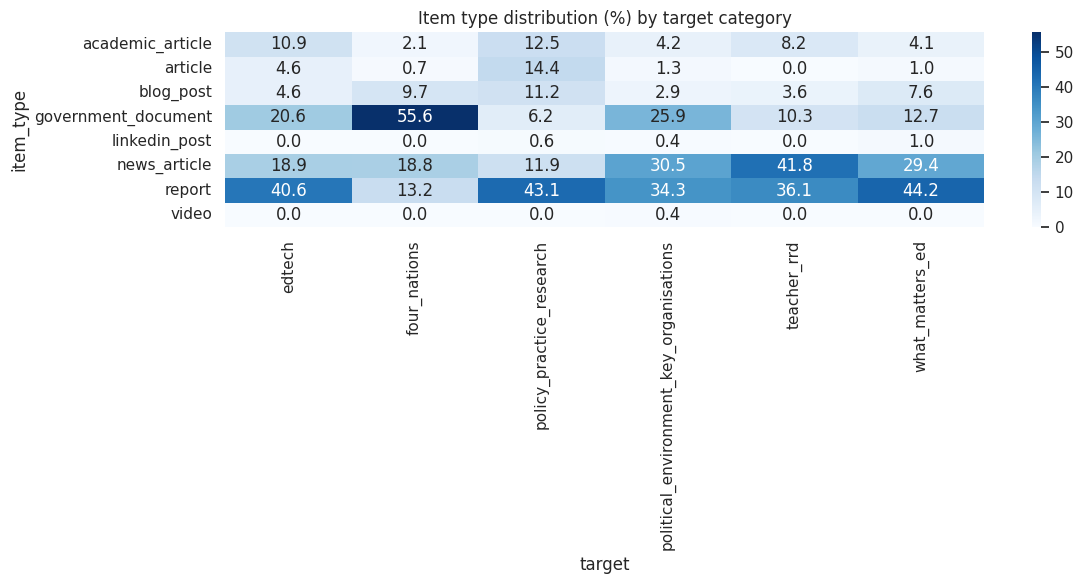

target,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
item_type,,,,,,
academic_article,10.900000,2.100000,12.500000,4.200000,8.200000,4.100000
article,4.600000,0.700000,14.400000,1.300000,0.000000,1.000000
blog_post,4.600000,9.700000,11.200000,2.900000,3.600000,7.600000
government_document,20.600000,55.600000,6.200000,25.900000,10.300000,12.700000
linkedin_post,0.000000,0.000000,0.600000,0.400000,0.000000,1.000000
news_article,18.900000,18.800000,11.900000,30.500000,41.800000,29.400000
report,40.600000,13.200000,43.100000,34.300000,36.100000,44.200000
video,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000


In [17]:
ct = pd.crosstab(df["item_type"], df["target"], normalize="columns").mul(100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Item type distribution (%) by target category")
plt.tight_layout()
plt.savefig("../outputs/item_type_by_target_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

ct.style.background_gradient(cmap="Blues")


**Item type by category:** Item type distributions vary across categories, suggesting it carries signal as a feature. `four_nations` is dominated by government documents (50.9%), `teacher_rrd` and `political_environment_key_organisations` skew heavily towards news articles, while `what_matters_ed` has the most diverse source mix including academic articles and blog posts. `government_document` is almost a giveaway for `four_nations`.


# 07_broad_org_category

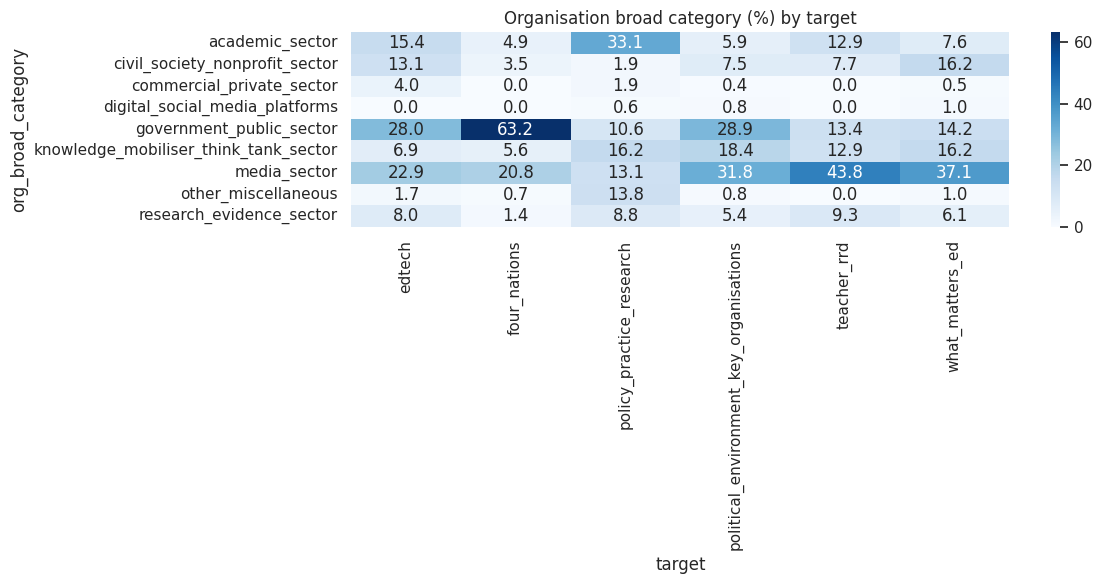

target,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
org_broad_category,,,,,,
academic_sector,15.400000,4.900000,33.100000,5.900000,12.900000,7.600000
civil_society_nonprofit_sector,13.100000,3.500000,1.900000,7.500000,7.700000,16.200000
commercial_private_sector,4.000000,0.000000,1.900000,0.400000,0.000000,0.500000
digital_social_media_platforms,0.000000,0.000000,0.600000,0.800000,0.000000,1.000000
government_public_sector,28.000000,63.200000,10.600000,28.900000,13.400000,14.200000
knowledge_mobiliser_think_tank_sector,6.900000,5.600000,16.200000,18.400000,12.900000,16.200000
media_sector,22.900000,20.800000,13.100000,31.800000,43.800000,37.100000
other_miscellaneous,1.700000,0.700000,13.800000,0.800000,0.000000,1.000000
research_evidence_sector,8.000000,1.400000,8.800000,5.400000,9.300000,6.100000


In [18]:
ct = pd.crosstab(df["org_broad_category"], df["target"], normalize="columns").mul(100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Organisation broad category (%) by target")
plt.tight_layout()
plt.savefig("../outputs/org_broad_category_by_target_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

ct.style.background_gradient(cmap="Blues")


**Organisation broad category by target:** Strong signal. `four_nations` is 63% government/public sector, `edtech` has the highest commercial/private sector share (29.5%), `what_matters_ed` is the most media-heavy (34.8%), and `teacher_rrd` has the highest knowledge/think tank representation (15.4%). Worth including as a feature.


# 08_Create dataset for preprocessing

In [19]:
df.columns

Index(['id', 'newsletter_number', 'issue_date', 'theme', 'subtheme', 'title',
       'description', 'link', 'new_theme', 'domain', 'organisation',
       'org_broad_category', 'org_category', 'item_type', 'title_length',
       'description_length', 'text', 'text_length_words', 'target'],
      dtype='object')

In [20]:
cols = ['id', 'newsletter_number', 'issue_date', 'link', 'target',  'text', 'organisation', 'org_broad_category', 'item_type' ]
df[cols].to_csv("../data/processed/eda_cleaned.csv", index=False)
print(f"Saved {len(df)} rows, {len(cols)} columns")


Saved 1109 rows, 9 columns


# 09_Summary

## Key findings
- 1,109 samples across 6 categories after cleaning (dropped curator categories, short text, unmapped domains)
- Sufficient for TF-IDF + logistic regression. Borderline for fine-tuning DistilBERT/BERT (doable with early stopping, low learning rate, 3-5 epochs). Too small for fine-tuning larger models (RoBERTa-large). Given the distinct vocabularies per category, TF-IDF will likely perform well enough that transformer fine-tuning may not be worth the added complexity.
- Class balance is mild (13.0%–21.6%) — stratified splits and `class_weight="balanced"` will handle it
- Categories have distinct vocabularies — TF-IDF will be effective as the main feature
- `item_type` and `org_broad_category` both vary across categories and carry signal as metadata features


## Dataset for preprocessing
- Saved to `data/processed/eda_cleaned.csv` (1,109 rows, 9 columns)
- Features: `text`, `target`, `item_type`, `organisation`, `org_broad_category`
- `text` = title + description combined — this is the main classifier input
- Preprocessing next steps: text cleaning, TF-IDF vectorisation, encode metadata features, stratified train/val split

## Pipeline requirements
- Create `text` variable by combining article title with first few sentences (matching training format)
- Derive `item_type` from keyword lookup, `organisation` from domain, `org_broad_category` from manual mapping
- If a new source is added to the scraping list, it must also be added to the organisation mapping table
- Keep input text consistent between training and inference — use short text, not full articles
